# Quoting Engine

A market maker quotes a bid/ask spread centered on a Black-Scholes fair value (placeholder until Heston surface lands).

Order arrivals are modeled with a Poisson process. The Avellaneda-Stoikov framework
derives optimal bid/ask quotes by computing a reservation price adjusted for inventory
risk, then placing a spread symmetrically around it. Fills are governed by a separate
exponential decay coefficient `k_fill` so that wider spreads genuinely reduce fill rates.

The notebook builds up from a single-expiry baseline to a full multi-expiry simulation
with portfolio-level delta netting across 6 TLT option expiries.

**Outputs:** bid/ask quotes, inventory paths per expiry, book-level P&L, hedge position,
and four-bucket P&L attribution (cash / MTM / hedge / costs).

In [1]:
#imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
from scipy.stats import norm

In [2]:
# grab Vasicek params from calibration
with open("../data/vasicek_params.json") as f:
    params = json.load(f)

r0       = params['r0']         # current spot rate
kappa_r  = params['kappa']      # rate mean reversion speed
theta_r  = params['theta']      # long-run mean rate
sigma_r  = params['sigma_r']    # rate volatility
# rho_rS: correlation between rate and TLT shocks (negative for TLT).
# Calibration assumption — should be moved into vasicek_params.json once
# Person A's calibration script supports it.
rho_rS   = params.get('rho_rS', -0.7)

# market snapshot - April 24th, 2026 close
S0 = 86.71  # TLT spot price

# TLT realized vol used for the simulated underlying GBM path.
# This is *underlying* vol, not option IV. Placeholder; should be calibrated
# from historical TLT returns. Set to 0.15 (~15% annualized) as a stand-in.
sigma_TLT = 0.15

# TEMPORARY: replace with Heston output when Person A's surface lands.
# fair_value below is just a seed BS ATM call price; the simulation
# reprices each day using current TLT, so these values only set day-0 anchor.
fair_value = {
    'May15': 1.34,
    'Jun18': 2.26,
    'Jul17': 2.86,
    'Aug21': 3.49,
    'Sep18': 3.95,
    'Oct16': 4.37
}
# Per-expiry implied vol — flat placeholder until Heston surface arrives.
# Renamed from `sigma` to `iv` to avoid shadowing scipy.stats.sigma conventions
# and to make the "implied vol" intent explicit.
iv = {
    'May15': 0.15, 'Jun18': 0.15, 'Jul17': 0.15,
    'Aug21': 0.15, 'Sep18': 0.15, 'Oct16': 0.15
}

# strike for each expiry — ATM at t=0 (will not move with TLT spot)
strike = {name: S0 for name in fair_value}

# option expiries — trading days to expiry expressed in years (1/252 convention)
expiries = {
    'May15':  21/252,
    'Jun18':  55/252,
    'Jul17':  84/252,
    'Aug21': 119/252,
    'Sep18': 147/252,
    'Oct16': 175/252
}

# ---- market making parameters ----
# NAMING NOTE (audit fix): in Avellaneda-Stoikov 2008, the spread formula uses κ,
# the *fill-probability decay coefficient* — the parameter that ties spread width
# to how aggressively wider quotes get penalized. The Poisson *arrival rate* (A in
# A-S) is a separate quantity. We previously called the arrival rate `kappa_MM`,
# which collided with the A-S κ. Renamed for clarity:
#   arrival_rate  ← (was kappa_MM)  Poisson arrival intensity per side per year
#   k_fill        ← unchanged       fill-probability decay coefficient (the A-S κ)
gamma                   = 0.5   # risk aversion: higher = wider spreads, more inventory skew
arrival_rate            = 200    # Poisson order arrival rate (per year per side per expiry)
k_fill                  = 30    # fill-probability decay coefficient (the A-S κ)
                                # higher = wider quotes are penalized more heavily
max_inventory           = 3     # hard inventory limit per expiry per side
max_portfolio_inventory = 10    # cap on |sum of inventory across all expiries|

# ---- transaction costs ----
tc_per_share    = 0.01  # $/share on TLT hedge rebalances
tc_per_contract = 0.02  # $/contract on option fills (both bid and ask side)

print(f"r0: {r0:.4f}")
print(f"S0: {S0}")
print(f"sigma_TLT (underlying realized vol): {sigma_TLT}")
print(f"gamma: {gamma}, arrival_rate: {arrival_rate}, k_fill: {k_fill}")
print(f"max_inv: {max_inventory}, max_port_inv: {max_portfolio_inventory}")
print(f"tc_per_share: {tc_per_share}, tc_per_contract: {tc_per_contract}")


r0: 0.0369
S0: 86.71
sigma_TLT (underlying realized vol): 0.15
gamma: 0.5, arrival_rate: 200, k_fill: 30
max_inv: 3, max_port_inv: 10
tc_per_share: 0.01, tc_per_contract: 0.02


### Avellaneda-Stoikov

Academic standard for options market making. The core idea: you don't quote symmetrically around fair value - you skew your quotes based on your inventory to manage risk.

Three formulas:
$$r_{price} = \text{fair\_value} - \text{inventory} \cdot \gamma \cdot \sigma^2 \cdot (T - t)$$

$$\text{spread} = \gamma \cdot \sigma^2 \cdot (T-t) + \frac{2}{\gamma} \ln\left(1 + \frac{\gamma}{\kappa_{MM}}\right)$$

$$\text{bid} = r_{price} - \frac{\text{spread}}{2}, \quad \text{ask} = r_{price} + \frac{\text{spread}}{2}$$

Parameters:
* $\gamma$      : Our risk aversion. Higher = wider spreads, more aggressive inventory skew
* $\kappa_{MM}$ : Rate at which orders arrive. Higher = tighter spreads (more flow = less need to widen)
* $T$           : Expiration of the option
* $t$           : current time (start at 0)
* inventory     : Start at zero

In [3]:
# parameters — quick sanity check on May15 expiry
T = expiries['May15']
t = 0.0
inventory = 0

# pull values for this single test
fv  = fair_value['May15']
vol = iv['May15']

# A-S calculations — the κ in the spread formula is k_fill (the fill-probability
# decay coefficient), which is what A-S theory ties to spread width. The Poisson
# arrival_rate does NOT enter this formula directly.
r_price = fv - inventory * gamma * vol**2 * (T-t)
spread  = gamma * vol**2 * (T-t) + (2/gamma) * np.log(1 + (gamma/k_fill))
bid = r_price - (spread/2)
ask = r_price + (spread/2)

# sanity assertion (fix #14): bid must be strictly less than ask
assert bid < ask, f"Bid {bid} must be strictly less than ask {ask}"

print(f"r_price: {r_price:.4f}, spread: {spread:.4f}")
print(f"bid: {bid:.4f}, ask: {ask:.4f}")


r_price: 1.3400, spread: 0.0671
bid: 1.3065, ask: 1.3735


### Discrete Delta Hedging
Delta measures the sensitivity of our option's value to a `$1` move in TLT. A delta of 0.5 means if TLT moves up `$1`, our option gains `$0.50`.

As market makers we don't want to take a directional bet on TLT — we just 
want to capture spread. So we hedge delta by trading TLT shares to offset 
our option exposure, keeping us approximately direction-neutral.

We hedge discretely — once per day — rather than continuously. This is 
realistic since continuous hedging is impossible in practice and incurs 
infinite transaction costs. The gap between our discrete hedge and the 
theoretically perfect continuous hedge is called **delta hedge slippage**, 
which we will track as part of our P&L attribution.

Delta is calculated using the Black-Scholes formula — not for pricing, 
but as a translation tool to convert our Heston fair value into a 
hedgeable Greeks exposure.

In [4]:
def bs_delta(S, K, r, sigma, T):
    """Black-Scholes delta of a European call."""
    if T <= 0:
        return 1.0 if S > K else 0.0
    d1 = (np.log(S/K) + (r + sigma**2 / 2) * T) / (sigma * np.sqrt(T))
    return norm.cdf(d1)

def bs_call_price(S, K, r, sigma, T):
    """Black-Scholes price of a European call.
    Used to reprice options each day until Heston surface arrives."""
    if T <= 0:
        return max(S - K, 0.0)
    d1 = (np.log(S/K) + (r + sigma**2 / 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

# quick sanity check on May15 expiry
print(f"BS delta (ATM May15): {bs_delta(S0, S0, r0, iv['May15'], expiries['May15']):.4f}")
print(f"BS price (ATM May15): {bs_call_price(S0, S0, r0, iv['May15'], expiries['May15']):.4f}")


BS delta (ATM May15): 0.5369
BS price (ATM May15): 1.6324


### TLT Price Path Simulation

We jointly simulate the short rate (Vasicek) and TLT price (GBM with time-varying drift)
over a 175-trading-day window. The rate-TLT correlation captures the empirical
'rates ↑ → TLT ↓' dynamic.

`sigma_TLT` is the **underlying** TLT realized vol (~15% annualized placeholder),
distinct from option implied vol `sigma[expiry]`. `dt = 1/252` for trading-day
consistency with the Vasicek calibration.

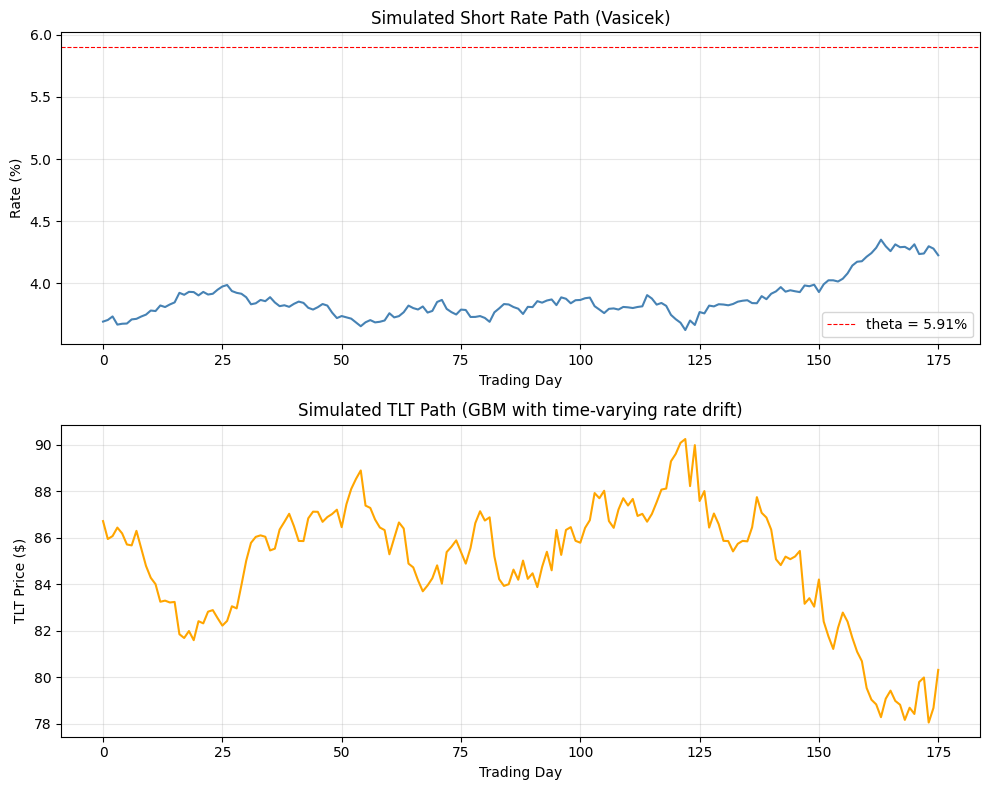

In [5]:
def simulate_coupled_paths(S0, r0, kappa_r, theta_r, sigma_r, sigma_S,
                           T_days, rho=-0.7, rng=None, seed=None):
    """
    Joint simulation of short rate (Vasicek) and TLT price (GBM with time-varying drift).

    The rate-TLT correlation captures the empirical 'rates -> TLT' dynamic.
    Uses dt = 1/252 (trading days), consistent with Vasicek calibration.

    AUDIT FIX (#5): accepts an `rng` (numpy Generator) so callers can keep their
    own independent random stream. Previously this function called
    `np.random.seed(seed)` which poisoned the *global* numpy RNG — every
    subsequent np.random.* call in run_simulation became deterministic
    conditional on the path seed, undermining Monte Carlo independence.

    If `rng` is None and `seed` is given, a fresh local Generator is built.
    The global numpy RNG is never touched.

    Returns:
        rate_path: array of length T_days+1, the simulated short rate
        tlt_path:  array of length T_days+1, the simulated TLT price
    """
    if rng is None:
        rng = np.random.default_rng(seed)

    dt = 1/252
    rates  = [r0]
    prices = [S0]

    for _ in range(T_days):
        # correlated Brownian shocks (drawn from the local rng, not global)
        z1 = rng.standard_normal()
        z2 = rng.standard_normal()
        dW_r = z1 * np.sqrt(dt)
        dW_S = (rho * z1 + np.sqrt(1 - rho**2) * z2) * np.sqrt(dt)

        # Vasicek step (Euler-Maruyama discretization)
        r_new = rates[-1] + kappa_r * (theta_r - rates[-1]) * dt + sigma_r * dW_r

        # TLT step with time-varying drift = current rate
        S_new = prices[-1] * np.exp((rates[-1] - 0.5 * sigma_S**2) * dt + sigma_S * dW_S)

        rates.append(r_new)
        prices.append(S_new)

    return np.array(rates), np.array(prices)


# quick sanity check + dual plot
sanity_rng = np.random.default_rng(42)
rate_path, tlt_path_test = simulate_coupled_paths(
    S0, r0, kappa_r, theta_r, sigma_r, sigma_TLT,
    T_days=175, rho=rho_rS, rng=sanity_rng
)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

ax1.plot(rate_path * 100, color='steelblue')
ax1.axhline(theta_r * 100, color='red', linestyle='--', linewidth=0.8, label=f'theta = {theta_r*100:.2f}%')
ax1.set_title('Simulated Short Rate Path (Vasicek)')
ax1.set_xlabel('Trading Day')
ax1.set_ylabel('Rate (%)')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(tlt_path_test, color='orange')
ax2.set_title('Simulated TLT Path (GBM with time-varying rate drift)')
ax2.set_xlabel('Trading Day')
ax2.set_ylabel('TLT Price ($)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### Poisson Order Arrival Simulation

At each daily time step, buyers and sellers arrive randomly via independent Poisson
processes with arrival rate `kappa_MM` per side. Not every arrival results in a fill —
fill probability decays exponentially with the quote's distance from fair value, governed
by `k_fill` (a *separate* parameter from `kappa_MM`). This captures adverse selection:
the further our quote is from fair value, the less likely an order fills.

`prob_fill = exp(-k_fill * distance_from_fv)`, clipped to [0, 1].

### Single-Expiry Simulation (May 15 only)

Baseline run on the May 15 expiry only. Used as a sanity check before scaling to the full multi-expiry portfolio below.

Final inventory:     -3
Bids filled:         2
Asks filled:         5
Cash P&L:            2.6852
Mark-to-market P&L:  -0.0000
Hedge P&L:           -2.1975
Transaction costs:   -0.1622
Total P&L:           0.3256
Current TLT shares:  0.0000


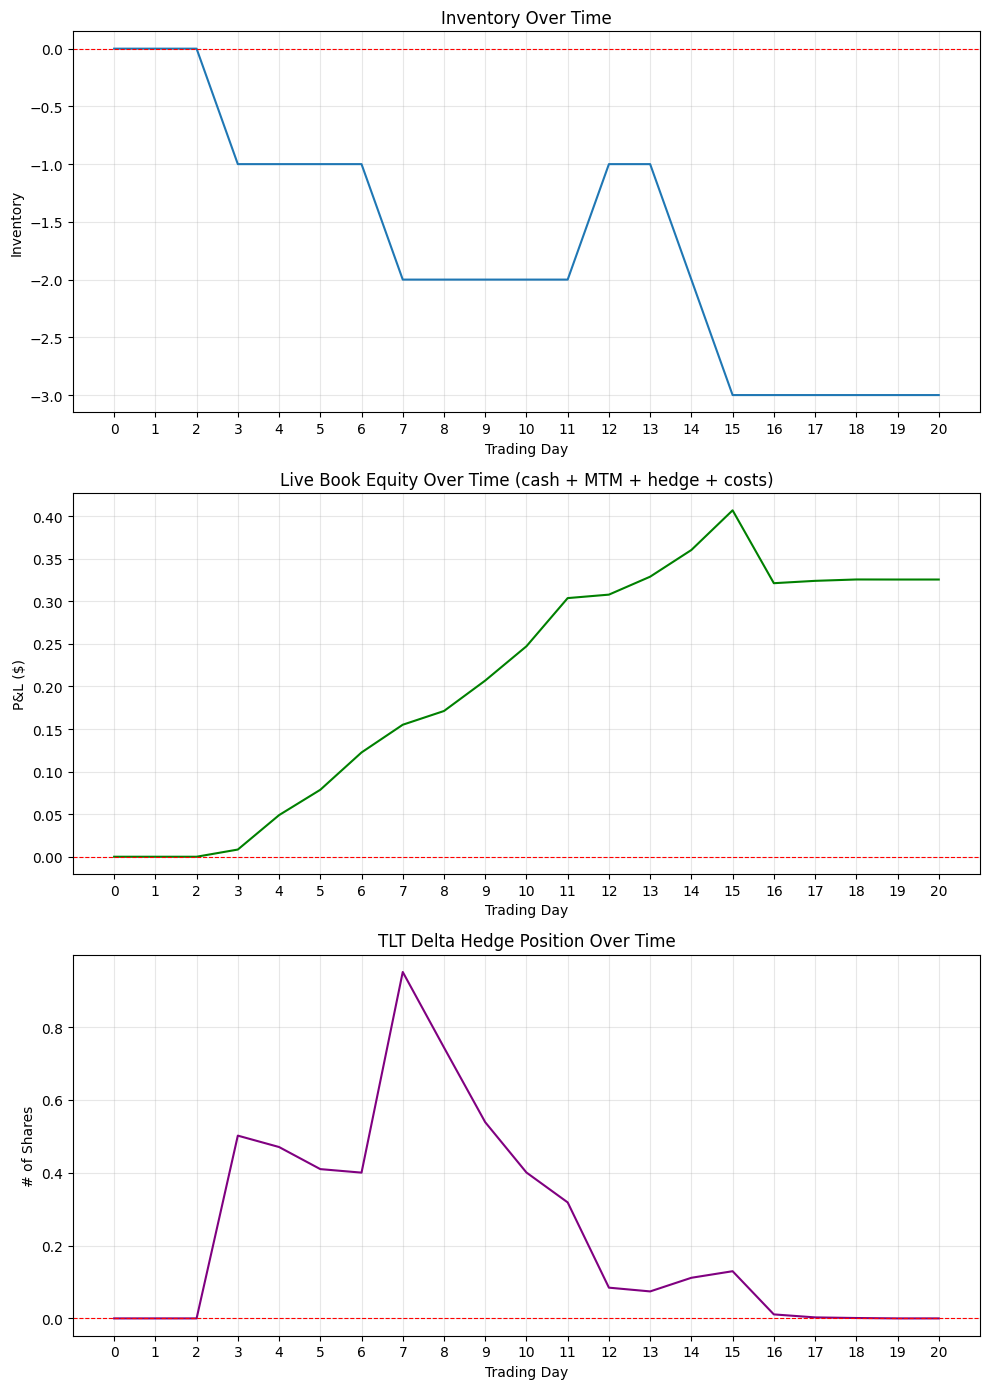

In [6]:
# single expiry baseline (May15 only)
# This is a sanity-check run before scaling to multi-expiry. Uses the same
# coupled rate+TLT path generator as the full sim for consistency.
#
# INDEX CONVENTION (audit fix #6): T_days=21 returns arrays of length 22
# (indices 0..21). We loop over days 0..20 (range(21)) for quoting/fills,
# then index path[21] = day-of-expiry value for the final intrinsic mark.
# So inside the loop, "day" is the *open* of that trading day; t = day/252.

T = expiries['May15']
K = strike['May15']
vol = iv['May15']

# fresh independent RNG for this single-expiry run (audit fix #5)
sim_rng = np.random.default_rng(42)

# generate path for this single run
rate_path_s, tlt_path_s = simulate_coupled_paths(
    S0, r0, kappa_r, theta_r, sigma_r, sigma_TLT,
    T_days=21, rho=rho_rS, rng=sim_rng
)

# initialize tracking variables
inventory = 0
bids_filled = 0
asks_filled = 0
cash_pnl = 0.0          # cumulative cash from spread capture (option fills)
hedge_pnl = 0.0         # cumulative P&L from TLT share position moving
cost_pnl = 0.0          # cumulative transaction costs (always negative)
current_shares = 0      # current TLT hedge position

inventory_track = []
total_pnl_track = []
shares_track = []

for day in range(21):
    t = day / 252  # trading-day convention
    time_to_exp = T - t

    # --- live BS reprice using today's TLT and rate ---
    # TEMPORARY: replace with Heston surface lookup when Person A delivers
    fv = bs_call_price(tlt_path_s[day], K, rate_path_s[day], vol, time_to_exp)

    # --- QUOTING (A-S) ---
    r_price = fv - inventory * gamma * vol**2 * time_to_exp
    spread  = gamma * vol**2 * time_to_exp + (2/gamma) * np.log(1 + (gamma/k_fill))
    bid = r_price - (spread/2)
    ask = r_price + (spread/2)
    assert bid < ask, f"Day {day}: bid {bid} must be < ask {ask}"  # fix #14

    # --- ORDER ARRIVALS (use sim_rng, not global) ---
    buyers  = sim_rng.poisson(arrival_rate / 252)
    sellers = sim_rng.poisson(arrival_rate / 252)

    # --- FILL PROBABILITY ---
    # uses k_fill (separate from arrival_rate); clipped to [0, 1] for safety
    prob_bid = np.clip(np.exp(-k_fill * max(fv - bid, 0)), 0.0, 1.0)
    prob_ask = np.clip(np.exp(-k_fill * max(ask - fv, 0)), 0.0, 1.0)

    # --- FILLS ---
    if inventory > -max_inventory:
        if buyers > 0 and sim_rng.random() < prob_ask:
            inventory -= 1
            asks_filled += 1
            cash_pnl += ask
            cost_pnl -= tc_per_contract

    if inventory < max_inventory:
        if sellers > 0 and sim_rng.random() < prob_bid:
            inventory += 1
            bids_filled += 1
            cash_pnl -= bid
            cost_pnl -= tc_per_contract

    # inventory cap assertion (fix #14)
    assert -max_inventory <= inventory <= max_inventory, \
        f"Day {day}: inventory {inventory} breached [{-max_inventory}, {max_inventory}]"

    # --- DELTA HEDGE ---
    # NOTE: single-expiry uses today's simulated rate (consistent with multi-expiry)
    delta = bs_delta(tlt_path_s[day], K, rate_path_s[day], vol, time_to_exp)
    target_shares = -inventory * delta

    # mark existing hedge to today's price BEFORE rebalancing
    if day > 0:
        hedge_pnl += current_shares * (tlt_path_s[day] - tlt_path_s[day - 1])

    # transaction cost on hedge rebalance
    cost_pnl -= tc_per_share * abs(target_shares - current_shares)
    current_shares = target_shares

    # --- DAILY SNAPSHOT ---
    # NOTE (audit fix #1): this curve = MTM-based equity, not cumulative spread.
    # cash_pnl is signed cash flow from fills (negative on buys, positive on sells),
    # and mtm_now offsets that on entry, so spread capture only shows up gradually
    # as inventory turns over. Read the curve as "live book equity" not "spread P&L".
    mtm_now = inventory * fv
    inventory_track.append(inventory)
    total_pnl_track.append(cash_pnl + mtm_now + hedge_pnl + cost_pnl)
    shares_track.append(current_shares)

# --- FINAL P&L ATTRIBUTION ---
# tlt_path_s[21] is the day-of-expiry value (T_days=21 => length 22 array)
final_fv = bs_call_price(tlt_path_s[21], K, rate_path_s[21], vol, 0.0)
mtm_pnl = inventory * final_fv
total_pnl = cash_pnl + mtm_pnl + hedge_pnl + cost_pnl

# bucket-sum identity (fix #14)
assert np.isclose(total_pnl, cash_pnl + mtm_pnl + hedge_pnl + cost_pnl), \
    "P&L bucket sum identity violated"

print(f"Final inventory:     {inventory}")
print(f"Bids filled:         {bids_filled}")
print(f"Asks filled:         {asks_filled}")
print(f"Cash P&L:            {cash_pnl:.4f}")
print(f"Mark-to-market P&L:  {mtm_pnl:.4f}")
print(f"Hedge P&L:           {hedge_pnl:.4f}")
print(f"Transaction costs:   {cost_pnl:.4f}")
print(f"Total P&L:           {total_pnl:.4f}")
print(f"Current TLT shares:  {current_shares:.4f}")

# --- PLOTS ---
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 14))

ax1.plot(range(21), inventory_track)
ax1.axhline(0, color='red', linestyle='--', linewidth=0.8)
ax1.set_title('Inventory Over Time')
ax1.set_xlabel('Trading Day')
ax1.set_ylabel('Inventory')
ax1.set_xticks(range(21))
ax1.grid(True, alpha=0.3)

ax2.plot(range(21), total_pnl_track, color='green')
ax2.axhline(0, color='red', linestyle='--', linewidth=0.8)
ax2.set_title('Live Book Equity Over Time (cash + MTM + hedge + costs)')
ax2.set_xlabel('Trading Day')
ax2.set_ylabel('P&L ($)')
ax2.set_xticks(range(21))
ax2.grid(True, alpha=0.3)

ax3.plot(range(21), shares_track, color='purple')
ax3.axhline(0, color='red', linestyle='--', linewidth=0.8)
ax3.set_title('TLT Delta Hedge Position Over Time')
ax3.set_xlabel('Trading Day')
ax3.set_ylabel('# of Shares')
ax3.set_xticks(range(21))
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### Multi-Expiry Simulation (Portfolio Delta Netting)

We now run the market maker across all 6 TLT expiries simultaneously.

**Key design decisions:**
- **One shared coupled rate + TLT path** — 175 trading days (longest expiry, Oct 16)
- **Per-expiry tracking** — inventory, P&L, hedge P&L, costs, fills stored in dicts
- **Live BS reprice each day** — `fv` computed from today's TLT, today's rate, and `sigma[expiry]`. *TEMPORARY:* swap for Heston surface lookup when Person A delivers.
- **Portfolio-level delta netting** — each day, sum delta × inventory across all active expiries, execute one shared TLT hedge trade
- **Delta-weighted hedge attribution** — hedge P&L allocated by each expiry's contribution to portfolio delta (not equal split)
- **Expiry dropout** — once `t >= T` for an expiry, we stop quoting it and lock in MTM at intrinsic value

**Risk limits:**
- `max_inventory = 3` — per-expiry concentration cap
- `max_portfolio_inventory = 10` — checked against the *post-fill* total to genuinely cap book exposure

**Costs:** $0.01/share on TLT rebalances + $0.02/contract on option fills, tracked as a 4th P&L bucket.

In [7]:
def run_simulation(seed=None, track_daily=False, track_drawdown=False):
    """
    Run one full multi-expiry market making simulation.

    Returns dict with cash/mtm/hedge/cost/total + per-expiry breakdowns.
    If track_daily=True, also includes daily-resolution paths for plotting.
    If track_drawdown=True (and track_daily=False), records *only* the daily
    book-equity series needed to compute max drawdown — cheaper than full
    per-expiry tracking. The Monte Carlo loop uses this mode.

    AUDIT NOTES:
      #1: `total_pnl_track` is *book equity* (cash + MTM + hedge + costs),
          NOT cumulative spread capture. Cash flows from fills are offset
          by inventory MTM on entry; spread shows up only as inventory turns
          over. Read the curve accordingly.
      #2: After an expiry hits T, mtm_locked[name] freezes at intrinsic. We
          stop quoting and stop accruing delta contributions, but hedge_pnl
          and cost_pnl already booked to that name remain in their totals.
      #3: Per-day order: (1) loop expiries, taking fills with TODAY's rng;
          (2) compute portfolio_delta from POST-fill inventory; (3) mark
          existing hedge using YESTERDAY's current_shares × today's price
          move (this is correct — yesterday's hedge was sized to yesterday's
          end-of-day delta); (4) rebalance to today's portfolio_delta.
      #4: Expiry iteration order is randomized each day to remove the
          systematic 'May15-gets-first-dibs-on-portfolio-cap' bias.
      #5: Uses a local np.random.Generator. Never touches global numpy RNG.
      #9: Hedge rebalance cost is split delta-weighted (matching hedge P&L
          attribution), not equally — idle expiries don't pay for active
          ones' rebalances.
      #14: Asserts bid<ask, inventory caps, and bucket-sum identity.
    """
    rng = np.random.default_rng(seed)

    # per-expiry state
    inventory   = {name: 0   for name in expiries}
    cash_pnl    = {name: 0.0 for name in expiries}
    hedge_pnl   = {name: 0.0 for name in expiries}
    cost_pnl    = {name: 0.0 for name in expiries}
    bids_filled = {name: 0   for name in expiries}
    asks_filled = {name: 0   for name in expiries}
    mtm_locked  = {name: None for name in expiries}

    # shared portfolio hedge
    current_shares = 0.0

    # daily tracking
    inventory_track = {name: [] for name in expiries}
    total_pnl_track = []
    shares_track    = []

    # joint rate + TLT path (use the same rng for path generation — keeps
    # everything in one independent stream per Monte Carlo run)
    rate_path, tlt_path = simulate_coupled_paths(
        S0, r0, kappa_r, theta_r, sigma_r, sigma_TLT,
        T_days=175, rho=rho_rS, rng=rng
    )

    expiry_names = list(expiries.keys())

    for day in range(175):
        t = day / 252
        portfolio_delta = 0.0
        per_expiry_delta_contrib = {}  # for hedge attribution

        # AUDIT FIX #4: shuffle iteration order each day to remove ordering bias
        # in the portfolio-cap check. Otherwise the first-iterated expiry
        # (May15) systematically wins the marginal slot when the book is full.
        order = expiry_names.copy()
        rng.shuffle(order)

        for name in order:
            T_exp = expiries[name]

            # expired? lock MTM at intrinsic and skip
            if t >= T_exp:
                if mtm_locked[name] is None:
                    K = strike[name]
                    intrinsic = max(tlt_path[day] - K, 0.0)
                    mtm_locked[name] = inventory[name] * intrinsic
                continue

            time_to_exp = T_exp - t
            inv = inventory[name]
            K   = strike[name]
            vol = iv[name]

            # --- live BS reprice (TEMPORARY until Heston) ---
            fv = bs_call_price(tlt_path[day], K, rate_path[day], vol, time_to_exp)

            # --- QUOTING ---
            r_price = fv - inv * gamma * vol**2 * time_to_exp
            spread  = gamma * vol**2 * time_to_exp + (2/gamma) * np.log(1 + (gamma/k_fill))
            bid = r_price - (spread/2)
            ask = r_price + (spread/2)
            assert bid < ask, f"Day {day} {name}: bid {bid} not < ask {ask}"  # fix #14

            # --- ORDER ARRIVALS (per trading day) ---
            buyers  = rng.poisson(arrival_rate / 252)
            sellers = rng.poisson(arrival_rate / 252)

            # --- FILL PROBABILITY ---
            prob_bid = np.clip(np.exp(-k_fill * max(fv - bid, 0)), 0.0, 1.0)
            prob_ask = np.clip(np.exp(-k_fill * max(ask - fv, 0)), 0.0, 1.0)

            # --- FILLS ---
            # Portfolio cap: check would-be total AFTER the fill, not before.
            # ask side: we sell, inventory[name] -= 1, total_inv -= 1
            total_inv = sum(inventory.values())
            if inv > -max_inventory and (total_inv - 1) >= -max_portfolio_inventory:
                if buyers > 0 and rng.random() < prob_ask:
                    inventory[name] -= 1
                    asks_filled[name] += 1
                    cash_pnl[name] += ask
                    cost_pnl[name] -= tc_per_contract

            # bid side: we buy, inventory[name] += 1, total_inv += 1
            total_inv = sum(inventory.values())
            if inv < max_inventory and (total_inv + 1) <= max_portfolio_inventory:
                if sellers > 0 and rng.random() < prob_bid:
                    inventory[name] += 1
                    bids_filled[name] += 1
                    cash_pnl[name] -= bid
                    cost_pnl[name] -= tc_per_contract

            # per-expiry inventory cap (fix #14)
            assert -max_inventory <= inventory[name] <= max_inventory, \
                f"Day {day} {name}: inventory {inventory[name]} breached caps"

            # --- DELTA CONTRIBUTION (post-fill) ---
            delta = bs_delta(tlt_path[day], K, rate_path[day], vol, time_to_exp)
            contrib = -inventory[name] * delta
            portfolio_delta += contrib
            per_expiry_delta_contrib[name] = contrib

        # portfolio cap assertion (fix #14)
        total_inv_eod = sum(inventory.values())
        assert abs(total_inv_eod) <= max_portfolio_inventory, \
            f"Day {day}: portfolio inventory {total_inv_eod} breached cap"

        # --- HEDGE: mark existing position, then rebalance ---
        if day > 0:
            price_move = tlt_path[day] - tlt_path[day - 1]
            hedge_gain = current_shares * price_move

            # delta-weighted attribution (instead of equal-split)
            total_abs_contrib = sum(abs(c) for c in per_expiry_delta_contrib.values())
            if total_abs_contrib > 1e-12:
                for name, contrib in per_expiry_delta_contrib.items():
                    weight = abs(contrib) / total_abs_contrib
                    hedge_pnl[name] += hedge_gain * weight
            else:
                # no active inventory anywhere -> distribute equally across active
                active = [n for n, T_exp in expiries.items() if t < T_exp]
                if active:
                    per = hedge_gain / len(active)
                    for name in active:
                        hedge_pnl[name] += per

        # --- HEDGE REBALANCE COST (audit fix #9: delta-weighted, not equal) ---
        # Rebalance size is driven by inventory changes per expiry; charging
        # idle expiries an equal share of the cost is wrong. Split using the
        # same delta-contribution weights as hedge P&L attribution.
        rebalance_cost = tc_per_share * abs(portfolio_delta - current_shares)
        if rebalance_cost > 0:
            total_abs_contrib = sum(abs(c) for c in per_expiry_delta_contrib.values())
            if total_abs_contrib > 1e-12:
                for name, contrib in per_expiry_delta_contrib.items():
                    weight = abs(contrib) / total_abs_contrib
                    cost_pnl[name] -= rebalance_cost * weight
            else:
                # fall back to equal split across active expiries
                active_now = [n for n, T_exp in expiries.items() if t < T_exp]
                if active_now:
                    per_cost = rebalance_cost / len(active_now)
                    for name in active_now:
                        cost_pnl[name] -= per_cost

        current_shares = portfolio_delta  # rebalance to net delta

        # daily snapshots (only when needed — audit fix #11)
        if track_daily or track_drawdown:
            book_total = 0.0
            for name in expiries:
                if mtm_locked[name] is not None:
                    mtm_n = mtm_locked[name]
                else:
                    T_exp = expiries[name]
                    K = strike[name]
                    fv_now = bs_call_price(tlt_path[day], K, rate_path[day], iv[name], T_exp - t)
                    mtm_n = inventory[name] * fv_now
                book_total += cash_pnl[name] + mtm_n + hedge_pnl[name] + cost_pnl[name]
            total_pnl_track.append(book_total)

            if track_daily:
                for name in expiries:
                    inventory_track[name].append(inventory[name])
                shares_track.append(current_shares)

    # ---- final aggregation ----
    final_t = 175 / 252
    cash_total  = sum(cash_pnl.values())
    hedge_total = sum(hedge_pnl.values())
    cost_total  = sum(cost_pnl.values())
    mtm_total = 0.0
    for name in expiries:
        if mtm_locked[name] is not None:
            mtm_total += mtm_locked[name]
        else:
            T_exp = expiries[name]
            K = strike[name]
            ttm = max(T_exp - final_t, 0.0)
            fv_final = bs_call_price(tlt_path[-1], K, rate_path[-1], iv[name], ttm)
            mtm_total += inventory[name] * fv_final

    total = cash_total + mtm_total + hedge_total + cost_total

    # bucket-sum identity (fix #14)
    assert np.isclose(total, cash_total + mtm_total + hedge_total + cost_total), \
        "P&L bucket sum identity violated"

    result = {
        'cash':        cash_total,
        'mtm':         mtm_total,
        'hedge':       hedge_total,
        'cost':        cost_total,
        'total':       total,
        'inventory':   inventory,
        'cash_pnl':    cash_pnl,
        'hedge_pnl':   hedge_pnl,
        'cost_pnl':    cost_pnl,
        'mtm_locked':  mtm_locked,
        'bids_filled': bids_filled,
        'asks_filled': asks_filled,
    }

    if track_daily:
        result['inventory_track'] = inventory_track
        result['total_pnl_track'] = total_pnl_track
        result['shares_track']    = shares_track
        result['tlt_path']        = tlt_path
        result['rate_path']       = rate_path
    elif track_drawdown:
        result['total_pnl_track'] = total_pnl_track

    return result


# --- BASELINE RUN (full daily tracking for plots) ---
result = run_simulation(seed=42, track_daily=True)

# extract for downstream cells
inventory       = result['inventory']
cash_pnl        = result['cash_pnl']
hedge_pnl       = result['hedge_pnl']
cost_pnl        = result['cost_pnl']
mtm_locked      = result['mtm_locked']
bids_filled     = result['bids_filled']
asks_filled     = result['asks_filled']
inventory_track = result['inventory_track']
total_pnl_track = result['total_pnl_track']
shares_track    = result['shares_track']
tlt_path_multi  = result['tlt_path']
rate_path_multi = result['rate_path']

# --- FINAL P&L ATTRIBUTION TABLE ---
print('=' * 88)
print(f"{'Expiry':<8} {'Inv':>5} {'Bids':>5} {'Asks':>5} {'Cash':>10} {'MTM':>10} {'Hedge':>10} {'Cost':>10} {'Total':>10}")
print("=" * 88)

final_t = 175 / 252
for name in expiries:
    inv = inventory[name]
    cash  = cash_pnl[name]
    if mtm_locked[name] is not None:
        mtm = mtm_locked[name]
    else:
        T_exp = expiries[name]
        ttm = max(T_exp - final_t, 0.0)
        mtm = inv * bs_call_price(tlt_path_multi[-1], strike[name], rate_path_multi[-1], iv[name], ttm)
    hedge = hedge_pnl[name]
    cost  = cost_pnl[name]
    total = cash + mtm + hedge + cost
    print(f"{name:<8} {inv:>5} {bids_filled[name]:>5} {asks_filled[name]:>5} "
          f"{cash:>10.4f} {mtm:>10.4f} {hedge:>10.4f} {cost:>10.4f} {total:>10.4f}")

print("=" * 88)
print(f"{'TOTAL':<8} {'':>5} {'':>5} {'':>5} "
      f"{result['cash']:>10.4f} {result['mtm']:>10.4f} {result['hedge']:>10.4f} {result['cost']:>10.4f} {result['total']:>10.4f}")


Expiry     Inv  Bids  Asks       Cash        MTM      Hedge       Cost      Total
May15        1     4     3    -2.4248     0.0000     0.2734    -0.1584    -2.3098
Jun18       -2    11    13     2.6707    -1.3334     1.0938    -0.5281     1.9030
Jul17       -1    14    15     0.8216    -0.0000    -1.6717    -0.6539    -1.5040
Aug21       -3    14    17     9.1030    -7.7104    -1.5877    -0.7221    -0.9173
Sep18       -3    36    39     2.4936    -0.0000     2.3512    -1.6562     3.1887
Oct16       -1    32    33     9.6899    -0.0000    -4.9004    -1.4990     3.2905
TOTAL                         22.3541    -9.0438    -4.4414    -5.2177     3.6511


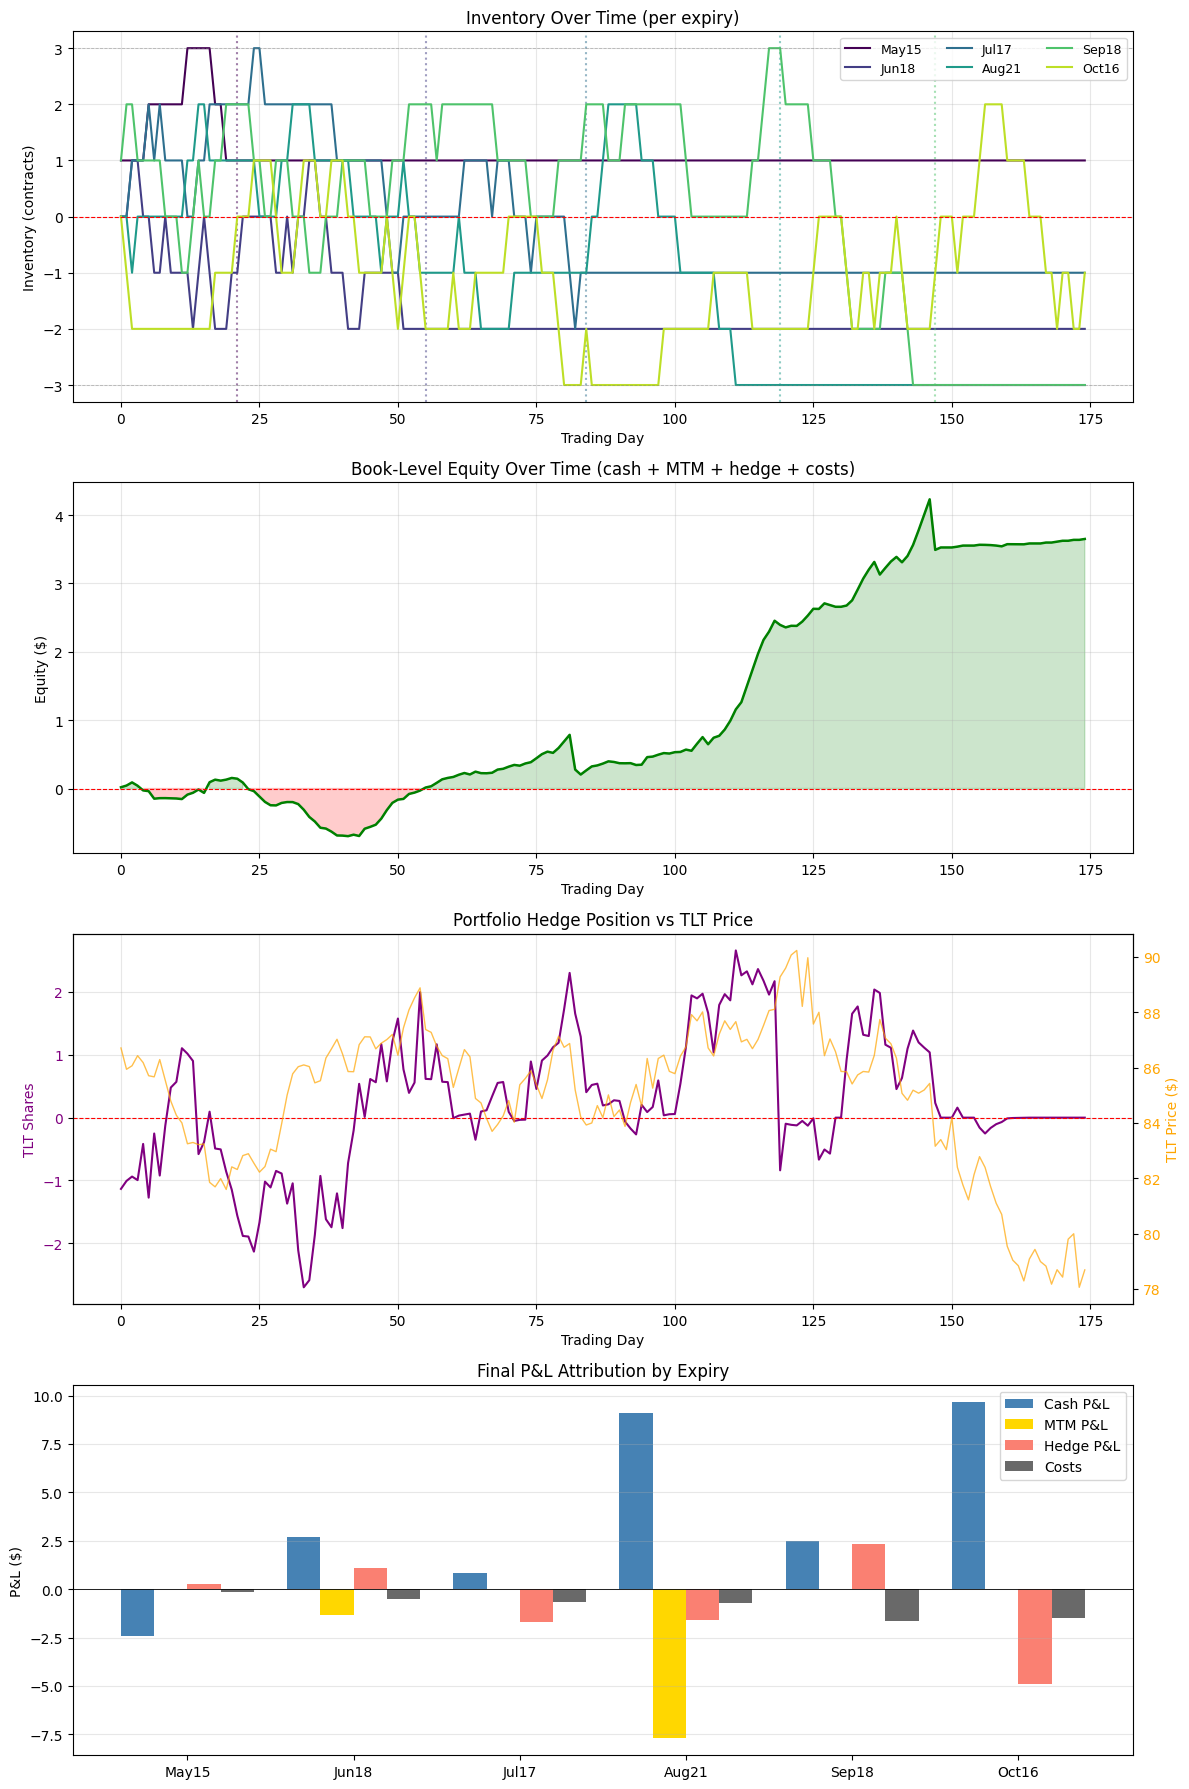

In [8]:
# --- MULTI-EXPIRY PLOTS ---
days = np.arange(175)

fig, axes = plt.subplots(4, 1, figsize=(12, 18))

# 1. INVENTORY PER EXPIRY
ax1 = axes[0]
plot_colors = plt.cm.viridis(np.linspace(0, 0.9, len(expiries)))
for (name, T_exp), color in zip(expiries.items(), plot_colors):
    ax1.plot(days, inventory_track[name], label=name, color=color, linewidth=1.5)
    expiry_day = int(T_exp * 252)
    if expiry_day < 175:
        ax1.axvline(expiry_day, color=color, linestyle=':', alpha=0.5)

ax1.axhline(0, color='red', linestyle='--', linewidth=0.8)
ax1.axhline( max_inventory, color='gray', linestyle='--', linewidth=0.6, alpha=0.5)
ax1.axhline(-max_inventory, color='gray', linestyle='--', linewidth=0.6, alpha=0.5)
ax1.set_title('Inventory Over Time (per expiry)')
ax1.set_xlabel('Trading Day')
ax1.set_ylabel('Inventory (contracts)')
ax1.legend(loc='upper right', ncol=3, fontsize=9)
ax1.grid(True, alpha=0.3)

# 2. CUMULATIVE BOOK-LEVEL EQUITY (NOT pure spread capture — see audit note #1)
ax2 = axes[1]
ax2.plot(days, total_pnl_track, color='green', linewidth=1.8)
ax2.axhline(0, color='red', linestyle='--', linewidth=0.8)
ax2.fill_between(days, 0, total_pnl_track,
                 where=np.array(total_pnl_track) >= 0, alpha=0.2, color='green')
ax2.fill_between(days, 0, total_pnl_track,
                 where=np.array(total_pnl_track) < 0,  alpha=0.2, color='red')
ax2.set_title('Book-Level Equity Over Time (cash + MTM + hedge + costs)')
ax2.set_xlabel('Trading Day')
ax2.set_ylabel('Equity ($)')
ax2.grid(True, alpha=0.3)

# 3. PORTFOLIO HEDGE WITH TLT OVERLAY
ax3 = axes[2]
ax3.plot(days, shares_track, color='purple', linewidth=1.5, label='TLT shares (hedge)')
ax3.axhline(0, color='red', linestyle='--', linewidth=0.8)
ax3.set_title('Portfolio Hedge Position vs TLT Price')
ax3.set_xlabel('Trading Day')
ax3.set_ylabel('TLT Shares', color='purple')
ax3.tick_params(axis='y', labelcolor='purple')
ax3.grid(True, alpha=0.3)

ax3b = ax3.twinx()
ax3b.plot(days, tlt_path_multi[:175], color='orange', linewidth=1, alpha=0.7, label='TLT price')
ax3b.set_ylabel('TLT Price ($)', color='orange')
ax3b.tick_params(axis='y', labelcolor='orange')

# 4. P&L ATTRIBUTION — 4 buckets per expiry
ax4 = axes[3]
expiry_names = list(expiries.keys())
cash_vals  = [cash_pnl[name] for name in expiry_names]
final_t_local = 175 / 252
mtm_vals = []
for name in expiry_names:
    if mtm_locked[name] is not None:
        mtm_vals.append(mtm_locked[name])
    else:
        ttm = max(expiries[name] - final_t_local, 0.0)
        mtm_vals.append(inventory[name] * bs_call_price(
            tlt_path_multi[-1], strike[name], rate_path_multi[-1], iv[name], ttm))
hedge_vals = [hedge_pnl[name] for name in expiry_names]
cost_vals  = [cost_pnl[name]  for name in expiry_names]

x = np.arange(len(expiry_names))
width = 0.2

ax4.bar(x - 1.5*width, cash_vals,  width, label='Cash P&L',  color='steelblue')
ax4.bar(x - 0.5*width, mtm_vals,   width, label='MTM P&L',   color='gold')
ax4.bar(x + 0.5*width, hedge_vals, width, label='Hedge P&L', color='salmon')
ax4.bar(x + 1.5*width, cost_vals,  width, label='Costs',     color='dimgray')

ax4.axhline(0, color='black', linewidth=0.6)
ax4.set_xticks(x)
ax4.set_xticklabels(expiry_names)
ax4.set_title('Final P&L Attribution by Expiry')
ax4.set_ylabel('P&L ($)')
ax4.legend()
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


### Monte Carlo Validation (1,000 paths)

Single-path results are noisy. Hedge P&L on any individual path can swing several
dollars purely from TLT random walk realization. To validate the MM strategy
itself, we run the multi-expiry simulation across 1,000 independent paths
and aggregate the P&L distribution.

**The thesis we're testing:**
- **Cash P&L (spread capture)** should be **positive in expectation** — this is the MM business model.
- **Hedge P&L** should be **approximately mean-zero** — TLT's random walk is symmetric, so over many paths the hedge gains and losses cancel.
- **Costs** should be **reliably negative** — every fill and rebalance pays a fixed fee.
- **Total P&L** = Cash − Costs ± Hedge ± MTM, should be positive in expectation if spreads sufficiently compensate for adverse selection and friction.

If hedge P&L is reliably non-zero, the hedge has structural bias. If cash − costs is mean-zero or negative, the spread isn't paying for the friction.

Completed 100/1000 runs
Completed 200/1000 runs
Completed 300/1000 runs
Completed 400/1000 runs
Completed 500/1000 runs
Completed 600/1000 runs
Completed 700/1000 runs
Completed 800/1000 runs
Completed 900/1000 runs
Completed 1000/1000 runs

Monte Carlo complete.

Bucket             Mean        Std        Min        Max   % Positive
Cash             7.7416    31.3383  -120.9125   166.2257        65.6%
MTM              1.1298    29.7360  -153.7147   194.1945        42.7%
Hedge           -1.3781    21.5794  -118.4591    87.0261        47.6%
Cost            -5.2693     0.4147    -6.7258    -4.0538         0.0%
Total            2.2240     2.4294    -7.8073    12.6350        82.8%

Information ratio (per 175-day window): 0.9155
Sharpe ratio (annualized):              1.0986
Mean max drawdown:                      -1.2202
Worst max drawdown:                     -5.9618
Median max drawdown:                    -0.9694


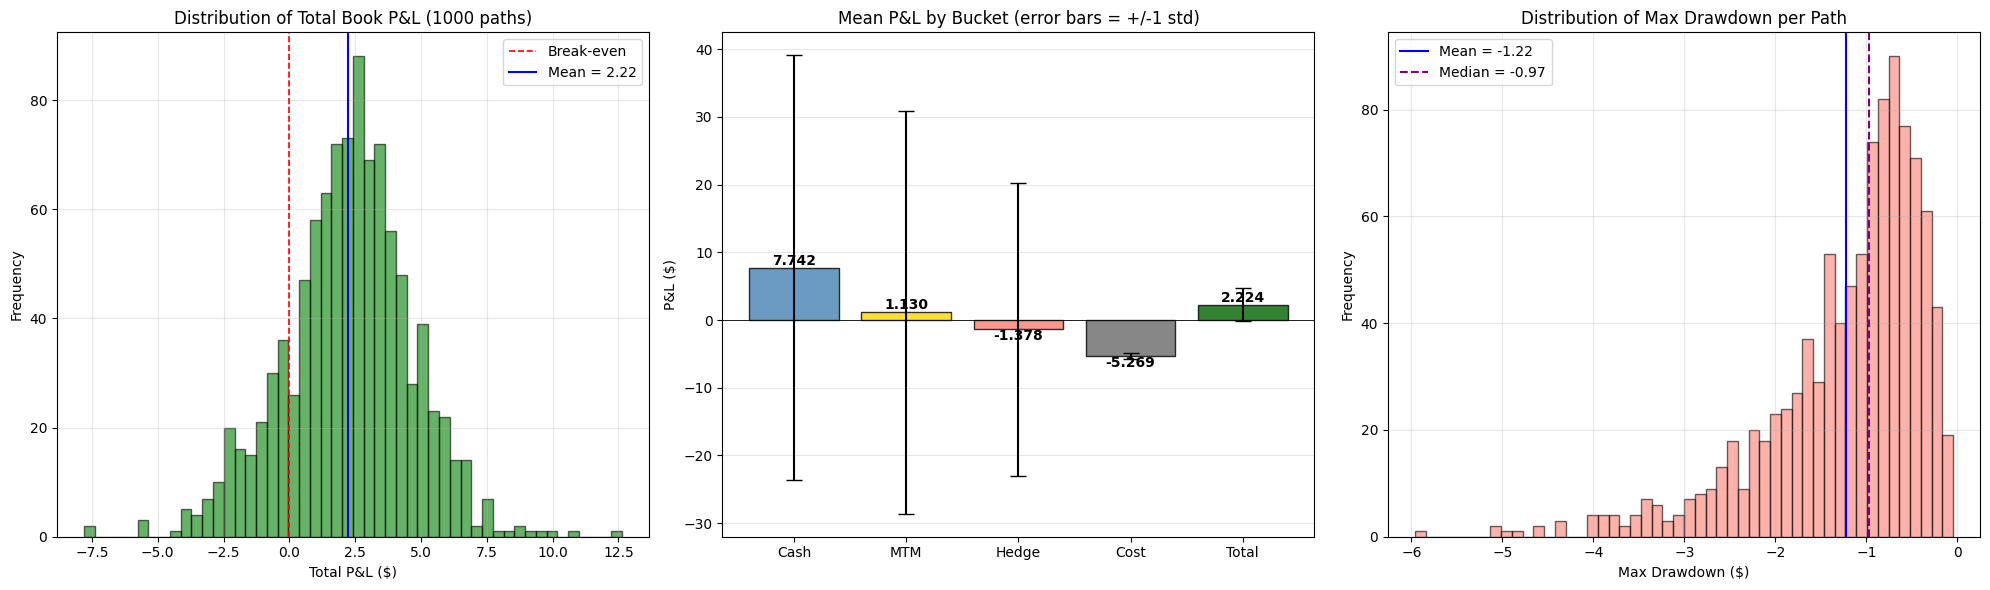

In [9]:
# --- MONTE CARLO: 1000 INDEPENDENT PATHS ---
# AUDIT FIX #11: use track_drawdown=True (lightweight) instead of track_daily=True.
# We only need the daily book-equity series for drawdown — no per-expiry inventory
# track or shares track is plotted in this section, so don't pay to record them.
N_RUNS = 1000

mc_cash   = np.zeros(N_RUNS)
mc_mtm    = np.zeros(N_RUNS)
mc_hedge  = np.zeros(N_RUNS)
mc_cost   = np.zeros(N_RUNS)
mc_total  = np.zeros(N_RUNS)
mc_max_dd = np.zeros(N_RUNS)

for run in range(N_RUNS):
    # Each run gets its own independent np.random.Generator (seeded by run idx).
    # Audit fix #5: run_simulation no longer poisons the global numpy RNG, so
    # the 1000 paths are now genuinely independent — order arrivals AND fills
    # AND price paths all draw from a single per-run Generator stream.
    run_result = run_simulation(seed=run, track_drawdown=True)
    mc_cash[run]  = run_result['cash']
    mc_mtm[run]   = run_result['mtm']
    mc_hedge[run] = run_result['hedge']
    mc_cost[run]  = run_result['cost']
    mc_total[run] = run_result['total']

    daily_pnl = np.array(run_result['total_pnl_track'])
    running_peak = np.maximum.accumulate(daily_pnl)
    drawdown = daily_pnl - running_peak
    mc_max_dd[run] = drawdown.min()

    if (run + 1) % 100 == 0:
        print(f"Completed {run + 1}/{N_RUNS} runs")

print("\nMonte Carlo complete.")

# --- DISTRIBUTION SUMMARY ---
print("\n" + "=" * 80)
print(f"{'Bucket':<12} {'Mean':>10} {'Std':>10} {'Min':>10} {'Max':>10} {'% Positive':>12}")
print("=" * 80)

for label, arr in [('Cash',  mc_cash),
                   ('MTM',   mc_mtm),
                   ('Hedge', mc_hedge),
                   ('Cost',  mc_cost),
                   ('Total', mc_total)]:
    pct_pos = 100 * np.mean(arr > 0)
    print(f"{label:<12} {arr.mean():>10.4f} {arr.std():>10.4f} "
          f"{arr.min():>10.4f} {arr.max():>10.4f} {pct_pos:>11.1f}%")

print("=" * 80)

# AUDIT FIX #10: annualized Sharpe ratio.
# Per-path total P&L covers a 175-trading-day window. To annualize the
# information ratio, multiply by sqrt(252/175). We report both for clarity.
window_days = 175
ir_window = mc_total.mean() / mc_total.std() if mc_total.std() > 0 else float('nan')
sharpe_annualized = ir_window * np.sqrt(252 / window_days)
print(f"\nInformation ratio (per 175-day window): {ir_window:.4f}")
print(f"Sharpe ratio (annualized):              {sharpe_annualized:.4f}")
print(f"Mean max drawdown:                      {mc_max_dd.mean():.4f}")
print(f"Worst max drawdown:                     {mc_max_dd.min():.4f}")
print(f"Median max drawdown:                    {np.median(mc_max_dd):.4f}")

# --- PLOTS ---
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

ax1 = axes[0]
ax1.hist(mc_total, bins=50, color='green', alpha=0.6, edgecolor='black')
ax1.axvline(0, color='red', linestyle='--', linewidth=1.2, label='Break-even')
ax1.axvline(mc_total.mean(), color='blue', linestyle='-', linewidth=1.5,
            label=f'Mean = {mc_total.mean():.2f}')
ax1.set_title(f'Distribution of Total Book P&L ({N_RUNS} paths)')
ax1.set_xlabel('Total P&L ($)')
ax1.set_ylabel('Frequency')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
buckets = ['Cash', 'MTM', 'Hedge', 'Cost', 'Total']
means   = [mc_cash.mean(), mc_mtm.mean(), mc_hedge.mean(), mc_cost.mean(), mc_total.mean()]
stds    = [mc_cash.std(),  mc_mtm.std(),  mc_hedge.std(),  mc_cost.std(),  mc_total.std()]
bar_colors = ['steelblue', 'gold', 'salmon', 'dimgray', 'darkgreen']

bars = ax2.bar(buckets, means, yerr=stds, capsize=6, color=bar_colors,
               edgecolor='black', alpha=0.8)
ax2.axhline(0, color='black', linewidth=0.6)
ax2.set_title('Mean P&L by Bucket (error bars = +/-1 std)')
ax2.set_ylabel('P&L ($)')
ax2.grid(True, alpha=0.3, axis='y')

for bar, m in zip(bars, means):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, height,
             f'{m:.3f}',
             ha='center', va='bottom' if height >= 0 else 'top',
             fontsize=10, fontweight='bold')

ax3 = axes[2]
ax3.hist(mc_max_dd, bins=50, color='salmon', alpha=0.6, edgecolor='black')
ax3.axvline(mc_max_dd.mean(), color='blue', linestyle='-', linewidth=1.5,
            label=f'Mean = {mc_max_dd.mean():.2f}')
ax3.axvline(np.median(mc_max_dd), color='purple', linestyle='--', linewidth=1.5,
            label=f'Median = {np.median(mc_max_dd):.2f}')
ax3.set_title('Distribution of Max Drawdown per Path')
ax3.set_xlabel('Max Drawdown ($)')
ax3.set_ylabel('Frequency')
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
